Import Libraries

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


Load Dataset

In [42]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print("Folder:", dirname)
    for filename in filenames:
        print("   ", filename)

Folder: /kaggle/input
Folder: /kaggle/input/datasets
Folder: /kaggle/input/datasets/mkashifn
Folder: /kaggle/input/datasets/mkashifn/nbaiot-dataset
    7.gafgyt.combo.csv
    9.gafgyt.combo.csv
    5.gafgyt.combo.csv
    1.mirai.udp.csv
    4.gafgyt.udp.csv
    6.gafgyt.udp.csv
    6.gafgyt.junk.csv
    data_summary.csv
    5.gafgyt.udp.csv
    9.gafgyt.junk.csv
    9.mirai.scan.csv
    1.benign.csv
    2.mirai.udpplain.csv
    3.gafgyt.combo.csv
    4.gafgyt.combo.csv
    6.mirai.scan.csv
    5.mirai.udp.csv
    3.benign.csv
    3.gafgyt.junk.csv
    7.gafgyt.scan.csv
    features.csv
    6.mirai.udp.csv
    6.gafgyt.tcp.csv
    6.gafgyt.combo.csv
    README.md
    6.mirai.syn.csv
    7.gafgyt.udp.csv
    5.gafgyt.junk.csv
    8.gafgyt.combo.csv
    7.gafgyt.junk.csv
    5.mirai.ack.csv
    4.mirai.syn.csv
    2.gafgyt.tcp.csv
    6.mirai.ack.csv
    2.mirai.ack.csv
    1.gafgyt.combo.csv
    6.mirai.udpplain.csv
    4.benign.csv
    2.gafgyt.scan.csv
    6.benign.csv
    4.mirai.udp.

In [43]:
benign = pd.read_csv("/kaggle/input/datasets/mkashifn/nbaiot-dataset/1.benign.csv")

In [44]:
benign.head()

,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_radius,HpHp_L0.1_covariance,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc
0,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,...,0.000000,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0
1,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,...,34.095047,0.0,0.0,5.319895,344.262695,4.710446,344.262695,22.188299,0.0,0.0
2,1.857879,360.458980,35.789338,1.912127,360.275733,35.923972,1.969807,360.091968,35.991542,1.996939,...,100.081513,0.0,0.0,6.318264,347.703087,9.034660,347.703087,81.625077,0.0,0.0
3,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,...,0.000000,0.0,0.0,1.000000,337.000000,0.000000,337.000000,0.000000,0.0,0.0
4,1.680223,172.140917,18487.448750,1.793580,182.560279,18928.175300,1.925828,193.165753,19153.795810,1.992323,...,0.000000,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0


Display First Five Rows

In [45]:
print(benign.shape)

(49548, 115)


In [46]:
print(benign.columns)

Index(['MI_dir_L5_weight', 'MI_dir_L5_mean', 'MI_dir_L5_variance',
       'MI_dir_L3_weight', 'MI_dir_L3_mean', 'MI_dir_L3_variance',
       'MI_dir_L1_weight', 'MI_dir_L1_mean', 'MI_dir_L1_variance',
       'MI_dir_L0.1_weight',
       ...
       'HpHp_L0.1_radius', 'HpHp_L0.1_covariance', 'HpHp_L0.1_pcc',
       'HpHp_L0.01_weight', 'HpHp_L0.01_mean', 'HpHp_L0.01_std',
       'HpHp_L0.01_magnitude', 'HpHp_L0.01_radius', 'HpHp_L0.01_covariance',
       'HpHp_L0.01_pcc'],
      dtype='object', length=115)


In [47]:
benign.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49548 entries, 0 to 49547
Columns: 115 entries, MI_dir_L5_weight to HpHp_L0.01_pcc
dtypes: float64(115)
memory usage: 43.5 MB


In [48]:
benign.describe()

,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_radius,HpHp_L0.1_covariance,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc
count,49548.000000,49548.000000,4.954800e+04,49548.000000,49548.000000,4.954800e+04,49548.000000,49548.000000,49548.000000,49548.000000,...,4.954800e+04,4.954800e+04,49548.000000,49548.000000,49548.000000,4.954800e+04,49548.000000,4.954800e+04,4.954800e+04,4.954800e+04
mean,2.256231,92.387127,1.989736e+01,2.288308,92.382667,2.549500e+01,2.422229,92.829655,67.670150,4.291791,...,8.968526e+00,1.806003e+00,0.000371,4.861666,92.338129,1.392164e-01,130.175018,9.643987e+00,2.138594e+00,1.775780e-03
std,1.453213,17.640932,3.591753e+02,1.469317,17.455677,3.770187e+02,1.505076,15.858976,436.114015,1.644405,...,2.919997e+02,7.661357e+01,0.013878,1.244585,17.928385,1.812241e+00,25.106333,2.914718e+02,8.120645e+01,2.521668e-02
min,1.000000,60.000000,0.000000e+00,1.000000,60.000000,0.000000e+00,1.000000,60.000000,0.000000,1.000000,...,0.000000e+00,-7.291934e+02,-0.142042,1.000000,60.000000,0.000000e+00,60.000000,0.000000e+00,-6.899823e+02,-1.353522e-01
25%,1.000000,97.999999,0.000000e+00,1.000029,97.976892,1.820000e-12,1.031097,93.553006,0.000808,2.878704,...,4.550000e-13,-1.780000e-35,0.000000,4.219096,98.000000,6.740000e-07,138.592929,1.820000e-12,-4.650000e-29,-7.242500e-18
50%,1.951958,101.999737,5.410000e-08,1.984559,101.985794,3.430290e-04,1.999986,101.337645,1.160150,4.241541,...,1.820000e-12,1.515000e-85,0.000000,4.220188,102.000000,1.350000e-06,144.249783,3.640000e-12,1.530000e-30,0.000000e+00
75%,3.121032,102.000000,2.594240e-04,3.398511,102.000000,1.687128e-01,3.969432,101.999583,42.268658,5.602002,...,3.640000e-12,3.950000e-34,0.000000,5.308375,102.000000,1.910000e-06,144.249783,5.140000e-12,7.530000e-29,2.000000e-17
max,8.837730,360.458980,2.123254e+04,10.876876,360.275733,2.138792e+04,14.488665,360.091968,20362.325690,20.148226,...,1.088123e+04,4.381892e+03,0.767997,11.283089,354.000000,5.890428e+01,688.052324,1.088186e+04,4.393551e+03,7.754023e-01


In [49]:
benign.isnull().sum()

MI_dir_L5_weight         0
MI_dir_L5_mean           0
MI_dir_L5_variance       0
MI_dir_L3_weight         0
MI_dir_L3_mean           0
                        ..
HpHp_L0.01_std           0
HpHp_L0.01_magnitude     0
HpHp_L0.01_radius        0
HpHp_L0.01_covariance    0
HpHp_L0.01_pcc           0
Length: 115, dtype: int64

In [50]:
print("Duplicates:", benign.duplicated().sum())

Duplicates: 9153


In [51]:
benign = benign.drop_duplicates()

In [56]:
import glob

# Add a label to benign data
benign['label'] = 'Benign'

# Get paths of a few attack files (or use a loop/list for specific ones)
attack_files = [
    "/kaggle/input/datasets/mkashifn/nbaiot-dataset/1.mirai.udp.csv",
    "/kaggle/input/datasets/mkashifn/nbaiot-dataset/4.gafgyt.udp.csv"
]

# Read and combine them
attack_list = []
for file in attack_files:
    temp_df = pd.read_csv(file)
    attack_list.append(temp_df)

attack = pd.concat(attack_list, ignore_index=True)
attack['label'] = 'Attack'

# Now your verification cell will run without error:
print(type(benign))
print(type(attack))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [57]:
print(type(benign))
print(type(attack))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [58]:
benign.head()

,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_covariance,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc,label
0,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,...,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0,Benign
1,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,...,0.0,0.0,5.319895,344.262695,4.710446,344.262695,22.188299,0.0,0.0,Benign
2,1.857879,360.458980,35.789338,1.912127,360.275733,35.923972,1.969807,360.091968,35.991542,1.996939,...,0.0,0.0,6.318264,347.703087,9.034660,347.703087,81.625077,0.0,0.0,Benign
3,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,...,0.0,0.0,1.000000,337.000000,0.000000,337.000000,0.000000,0.0,0.0,Benign
4,1.680223,172.140917,18487.448750,1.793580,182.560279,18928.175300,1.925828,193.165753,19153.795810,1.992323,...,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0,Benign


In [59]:
df = pd.concat([benign, attack], ignore_index=True)

print(df.shape)

(383842, 116)


In [60]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [61]:
print(df["label"].value_counts())

label
Attack    343447
Benign     40395
Name: count, dtype: int64


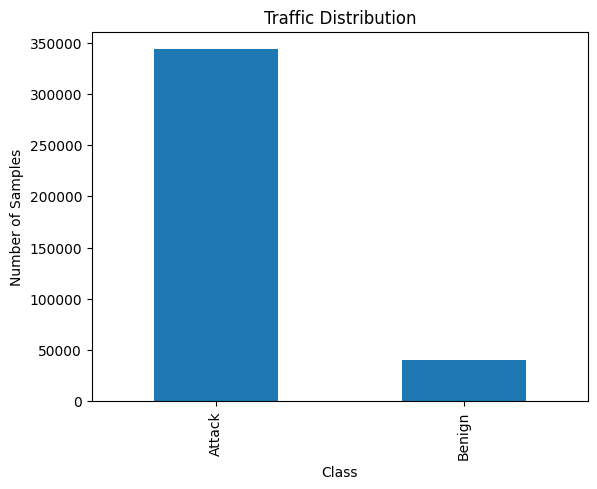

In [62]:
df["label"].value_counts().plot(kind="bar")

plt.title("Traffic Distribution")

plt.xlabel("Class")

plt.ylabel("Number of Samples")

plt.show()

In [63]:
encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["label"])

In [64]:
X = df.drop("label", axis=1)

y = df["label"]

In [65]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [67]:
print("Training Features:", X_train.shape)

print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)

print("Testing Labels:", y_test.shape)

Training Features: (307073, 115)
Testing Features: (76769, 115)
Training Labels: (307073,)
Testing Labels: (76769,)


In [68]:
train = pd.DataFrame(X_train)
train["label"] = y_train.values

train.to_csv("train_processed.csv", index=False)

test = pd.DataFrame(X_test)
test["label"] = y_test.values

test.to_csv("test_processed.csv", index=False)